# Imports and Style

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont('/home/vvelan/DarkLim/examples/styles/Times_New_Roman.ttf')

import matplotlib as mpl
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

plt.style.use('/home/vvelan/DarkLim/examples/styles/Style.mplstyle')

from multihist import Hist1d

from scipy import interpolate

from scipy.interpolate import interp1d

import darklim

import sys
sys.path.insert(0, 'ExistingLimits/')
import MichaelLimits as ML

import pandas as pd


%matplotlib inline

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

# Functions to plot existing data

In [2]:
def extrapolate(data, mass=1e6):
    m0, s0 = data[-1]
    return np.concatenate([data,[[mass, s0*mass/m0]]], axis=0)

def minbound(curves, masses=None):
    if masses is None:
        masses = np.logspace(-3, 4, 200)
    result = np.array([np.nan]*len(masses))
    for curve in curves:
        if curve[-1][0] < masses[-1]:
            curve = extrapolate(curve, masses[-1])
        yinterp = 10**(interp1d(*(np.log10(curve).T), bounds_error=False)(np.log10(masses)))
        #yinterp = interp1d(*(curve.T), bounds_error=False)(masses)
        result = np.nanmin([result, yinterp], axis=0)
    return np.array([masses, result]).T

def log_interp(zz, xx, yy, left=None, right=None):
    logz = np.log(zz)
    logx = np.log(xx)
    logy = np.log(yy)
    return np.exp(np.interp(logz, logx, logy, left=left, right=right))

def load_and_plot_existing(leg=True, lw=1, leg_params={}, ER_model='massless', cosmic=False, migdal=False, direct=False):
    
    curves_dir = 'ExistingLimits/'
    handles = []
    fig, ax = plt.subplots(1, 1, figsize=(10,7.5))
    ax.set_xscale('log')
    ax.set_yscale('log')
    mpl.rcParams['font.size'] = 14
    
    if ER_model == 'massive':

        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_ER_Massive_2025.txt').transpose()
        l, = ax.plot(m_lim*1e3, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025')
        handles.append(l)
        ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim_1, x_lim_1 = np.loadtxt(curves_dir + 'DAMIC_ER_Massive_2023.txt').transpose()
        m_lim_2, x_lim_2 = np.loadtxt(curves_dir + 'DAMIC_ER_Massive_2024.txt').transpose()
        m_lim = np.geomspace(min(m_lim_1[0], m_lim_2[0]), max(m_lim_1[-1], m_lim_2[-1]), 150)
        x_lim_1_adj = log_interp(m_lim, m_lim_1, x_lim_1, left=np.inf, right=np.inf)
        x_lim_2_adj = log_interp(m_lim, m_lim_2, x_lim_2, left=np.inf, right=np.inf)
        x_lim = np.minimum(x_lim_1_adj, x_lim_2_adj)
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='DAMIC 2023, 2024')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_ER_Massive_2023.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CE977A', lw=lw, label='Darkside-50 2023')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_ER_Massive.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_ER_Massive_2023.txt').transpose()
        l, = ax.plot(m_lim*1e3, x_lim, '--', color='#CA778C', lw=lw, label='PandaX-4T 2023')
        handles.append(l)
        ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'Freeze_out_Scalar_ER_Massive.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='orange', lw=lw*2, label='Freeze-out Scalar')
        handles.append(l)

        #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_S2Only_Solar_Reflected_ER_Massive.txt').transpose()
        #ax.plot(m_lim, x_lim, '--', lw=1.5, label='XENON1T S2only (Solar Refl.)')
        #m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_Solar_Reflection_ER_Massive.txt').transpose()
        #ax.plot(m_lim, x_lim, '--', lw=1.5, label='SENSEI SNOLAB (Solar Refl.)')

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    elif ER_model == 'massless':
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_ER_Massless_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim_1, x_lim_1 = np.loadtxt(curves_dir + 'DAMIC_ER_Massless_2023.txt').transpose()
        m_lim_2, x_lim_2 = np.loadtxt(curves_dir + 'DAMIC_ER_Massless_2024.txt').transpose()
        m_lim = np.geomspace(min(m_lim_1[0], m_lim_2[0]), max(m_lim_1[-1], m_lim_2[-1]), 150)
        x_lim_1_adj = log_interp(m_lim, m_lim_1, x_lim_1, left=np.inf, right=np.inf)
        x_lim_2_adj = log_interp(m_lim, m_lim_2, x_lim_2, left=np.inf, right=np.inf)
        x_lim = np.minimum(x_lim_1_adj, x_lim_2_adj)
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='DAMIC 2023, 2024')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_ER_Massless.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'Freeze_in_ER_Massless.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='#FF9039', lw=lw*2, label='Freeze-in')
        handles.append(l)

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    elif ER_model == 'absorption':

        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_Absorption_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-8, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_Absorption_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-8, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Absorption_2019.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='XENON1T 2019')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-8, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2022.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='#FF9039', lw=lw*2, label='XENONnT 2022')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-8, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2024_Lower.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw, label='XENONnT 2024')
        handles.append(l)

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2024_Upper.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw)
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-8, facecolor='whitesmoke')

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    else:

        if cosmic:

            m_lim = ML.Data_Cosmic_ray[:,0]
            x_lim = ML.Data_Cosmic_ray[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-.', label="Cosmic ray scattered DM")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')

            m_lim = ML.Data_Milky_way_satellites_2021[:,0]
            x_lim = ML.Data_Milky_way_satellites_2021[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='--', label="Milky Way satellites")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')

            m_lim = ML.Data_Ly_alpha_2022[:,0]
            x_lim = ML.Data_Ly_alpha_2022[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle=':', label="Ly-alpha forest")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')
            
            m_lim = ML.Data_CMB[:,0]
            x_lim = ML.Data_CMB[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-', label="CMB")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')
            
        if migdal:
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_Migdal_2025.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CFC0E5', linestyle='--', label='LBC (DAMIC) Migdal 2025')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_Migdal_NR.txt').transpose()
            l, = ax.plot(m_lim, x_lim, lw=lw, color='#CE977A', linestyle='--', label='SENSEI Migdal NR')
            handles.append(l)
            ax.fill_between(m_lim, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt').transpose()
            l, ax.plot(m_lim*1e3, x_lim, lw=lw, color='#a4dbed', linestyle='--', label='Darkside-50 Migdal 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CA778C', linestyle='--', label='PandaX4T Migdal 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Migdal_2019.txt').transpose()
            l, ax.plot(m_lim*1e3, x_lim, lw=lw, color='#FF9039', linestyle='--', label='XENON1T Migdal 2019')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)

            ### SuperCDMS Migdal 2023 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'SuperCDMS_Migdal_2023.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'SuperCDMS_Migdal_2023_Overburden.txt').transpose()
            
            m_range = np.geomspace( min(m_lim[0], m_lim_overburden[0]), max(m_lim[-1], m_lim_overburden[-1]), 150 )
            l, = ax.plot(m_range*1e3, log_interp(m_range, m_lim, x_lim), lw=lw, color='magenta', linestyle='--', label='SuperCDMS Migdal 2023')
            handles.append(l)
            ax.plot(m_range*1e3, log_interp(m_range, m_lim_overburden, x_lim_overburden), lw=lw, color='magenta', linestyle='--')
            ax.plot([m_lim[0]*1e3, m_lim[0]*1e3], [x_lim[0], x_lim_overburden[0]], lw=lw, color='magenta', linestyle='--')
            ax.fill_between(m_range*1e3,
                            log_interp(m_range, m_lim, x_lim),
                            log_interp(m_range, m_lim_overburden, x_lim_overburden),
                            facecolor='#ad8150', alpha=0.1)
            
        if direct:
        
            ### SuperCDMS CPD ###
            m_lim, x_lim = ML.cpdlimit_down[:,0], ML.cpdlimit_down[:,1]
            m_lim_overburden, x_lim_overburden = ML.cpdlimit_up[:,0], ML.cpdlimit_up[:,1]
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CE977A', linestyle='-', label='SuperCDMS CPD')
            handles.append(l)
            ax.plot(m_lim_overburden*1e3, x_lim_overburden, lw=lw, color='#CE977A', linestyle='-')
            ax.plot([m_lim[0]*1e3, m_lim[0]*1e3], [x_lim[0], x_lim_overburden[0]], lw=lw, color='#CE977A', linestyle='-')
            ax.fill_between(m_lim*1e3, x_lim, x_lim_overburden, facecolor='#dbdbdb', alpha=0.75)

            ### CRESST-III 2019 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2019.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='#a4dbed', lw=lw, label='CRESST-III 2019')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, max(x_lim), facecolor='#dbdbdb', alpha=0.75)

            ### CRESST-III 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2024_Extended.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'CRESST_III_2024_Overburden.txt').transpose()

            # Find point of intersection between limit and overburden
            m_range = np.geomspace( max(m_lim[0], m_lim_overburden[0]), min(m_lim[-1], m_lim_overburden[-1]), 150 )
            idx_intersect = np.argmin(
                np.abs(
                    np.log(np.interp(m_range, m_lim_overburden, x_lim_overburden, left=0., right=0.)) - 
                        np.log(np.interp(m_range, m_lim, x_lim, left=0., right=0.))
                )
            )

            # Plot excluded region
            m_plot = m_range[idx_intersect:]
            l, = ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.), linestyle='-', color='#CFC0E5', lw=lw, label='CRESST-III 2024')
            handles.append(l)
            ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim_overburden*1e3, x_lim_overburden, left=0., right=0.), linestyle='-', color='#CFC0E5', lw=lw)
            ax.fill_between(m_plot*1e3,
                            log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.),
                            log_interp(m_plot*1e3, m_lim_overburden*1e3, x_lim_overburden, left=0., right=0.),
                            facecolor='#dbdbdb', alpha=0.75)

            ### TESSERACT 2025 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'TESSERACT_2025_Limit.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'TESSERACT_2025_Overburden.txt').transpose()
            m_lim_pileup, x_lim_pileup = np.loadtxt(curves_dir + 'TESSERACT_2025_Pileup.txt').transpose()
            
            # Find point of intersection between limit and pileup
            m_range = np.geomspace( min(m_lim[0], m_lim_overburden[0], m_lim_pileup[0]), min(m_lim[-1], m_lim_overburden[-1], m_lim_pileup[-1]), 150 )
            idx_intersect = np.argmin(
                np.abs(
                    np.log(np.interp(m_range, m_lim_pileup, x_lim_pileup, left=0., right=0.)) - 
                        np.log(np.interp(m_range, m_lim, x_lim, left=0., right=0.))
                )
            )
            
            # Plot excluded region
            m_plot = m_range[idx_intersect:]
            l, = ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.), linestyle='-', color='#CA778C', lw=lw, label='TESSERACT 2025')
            handles.append(l)
            ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim_pileup*1e3, x_lim_pileup, left=0., right=0.), linestyle='-', color='#CA778C', lw=lw)
            ax.fill_between(m_plot*1e3,
                            log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.),
                            log_interp(m_plot*1e3, m_lim_pileup*1e3, x_lim_pileup, left=0., right=0.),
                            facecolor='#dbdbdb', alpha=0.75)


        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)
            
    return fig, ax, handles

/tmp/ipykernel_3880897/3619271564.py:139: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=handles, **leg_params)


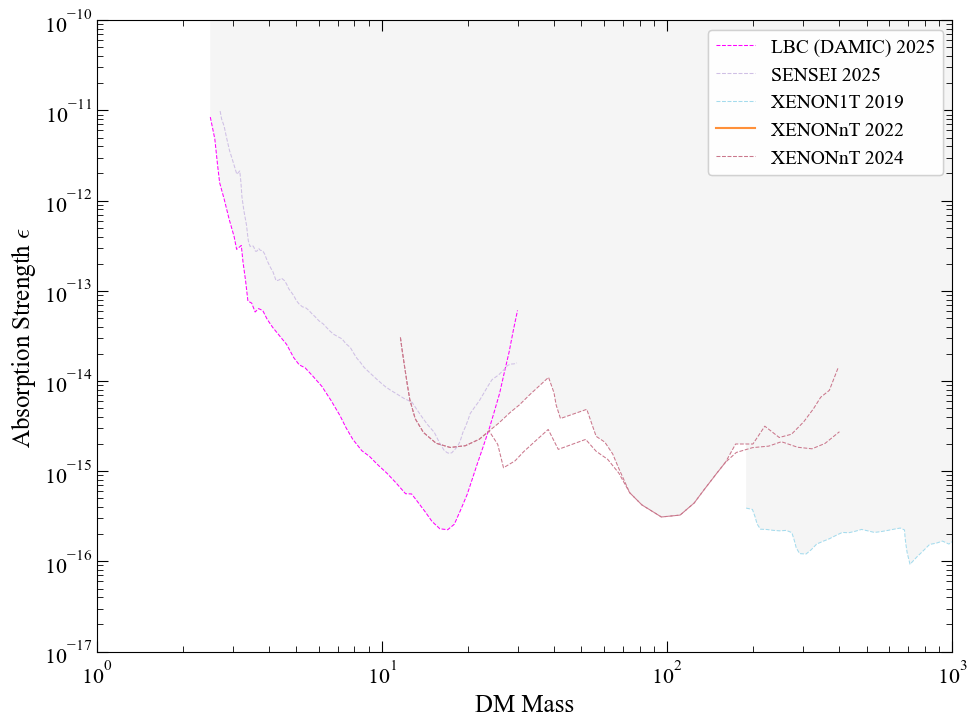

In [3]:
fig, ax, handles = load_and_plot_existing(ER_model='absorption', lw=0.75, leg=True, leg_params={'loc': 'upper right', 'fontsize': 14})

ax.set_xlim([1e0, 1e3])
ax.set_ylim([1e-17, 1e-10])
ax.set_xlabel(r'DM Mass', fontsize=18)
ax.set_ylabel(r'Absorption Strength $\epsilon$', fontsize=18)

fig.tight_layout()
fig.show()

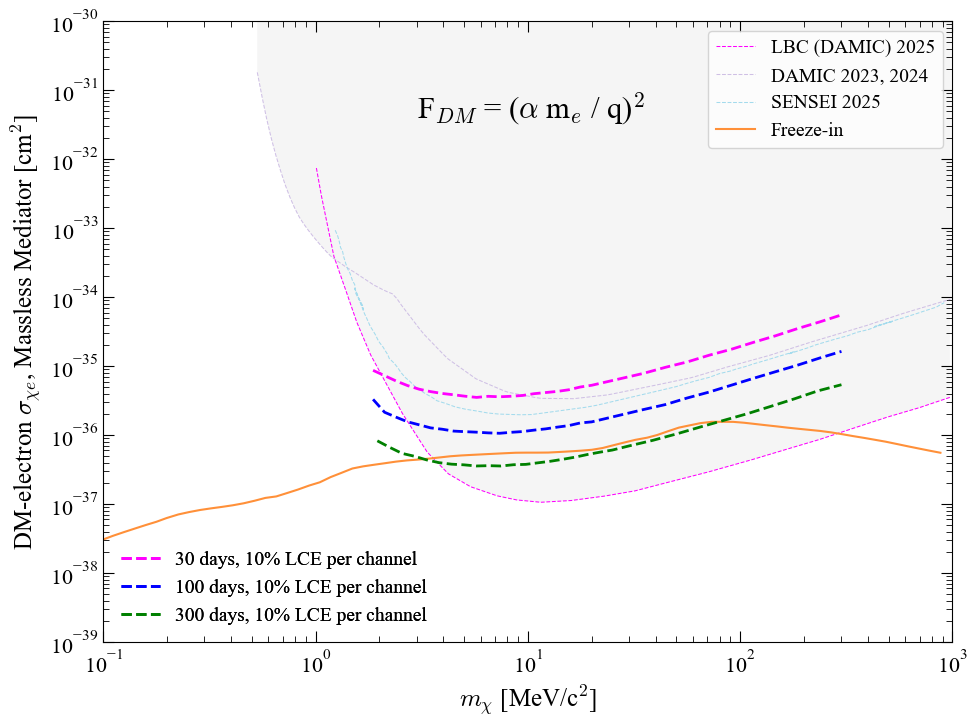

In [4]:
fig, ax, handles = load_and_plot_existing(ER_model='massless', lw=0.75, leg=True, leg_params={'loc': 'upper right', 'fontsize': 14})

handles_sens = []
m_limit, x_limit = np.loadtxt('gaas_for_review/results_gaas_oi_electron_massless_030days_3fold_lce10/HeRALD_FC_30d_3device_3fold_100mus.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='magenta', ls='--', lw=2, label='30 days, 10% LCE per channel')
handles_sens.append(lh)

m_limit, x_limit = np.loadtxt('gaas_for_review/results_gaas_oi_electron_massless_100days_3fold_lce10/HeRALD_FC_100d_3device_3fold_100mus.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='blue', ls='--', lw=2, label='100 days, 10% LCE per channel')
handles_sens.append(lh)

m_limit, x_limit = np.loadtxt('gaas_for_review/results_gaas_oi_electron_massless_300days_3fold_lce10/HeRALD_FC_300d_3device_3fold_100mus.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='green', ls='--', lw=2, label='300 days, 10% LCE per channel')
handles_sens.append(lh)

ax.text(3e0, 4e-32, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$', fontsize=22)

leg1 = ax.legend(handles=handles_sens, loc='lower left', fontsize=14, frameon=False)
ax.add_artist(leg1)

ax.set_xlim([1e-1, 1e3])
ax.set_ylim([1e-39, 1e-30])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massless Mediator [cm$^2$]', fontsize=18)

fig.tight_layout()
fig.show()

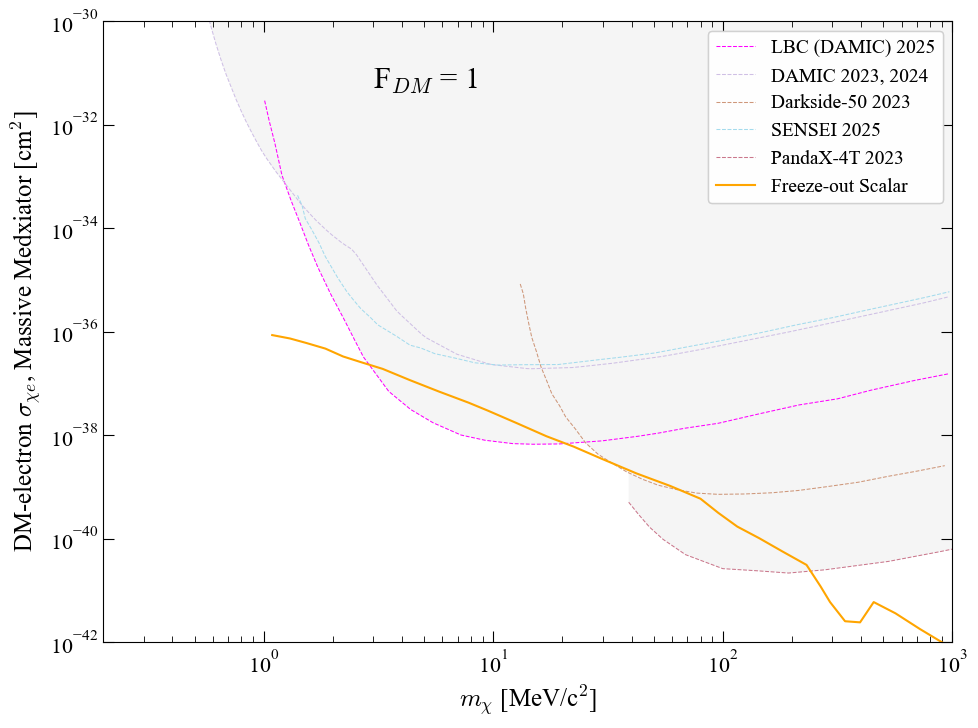

In [5]:
fig, ax, handles = load_and_plot_existing(ER_model='massive', lw=0.75, leg=True, leg_params={'loc': 'upper right', 'fontsize': 14})

# handles_sens = []

# m_limit, x_limit = np.loadtxt('gaas_for_review/results_gaas_oi_electron_massive_030days_3fold_lce10/HeRALD_FC_30d_3device_3fold_100mus.txt', unpack=True)
# lh, = plt.plot(m_limit*1e3, x_limit, color='magenta', ls='--', lw=2, label='30 days, 10% LCE per channel')
# handles_sens.append(lh)

# m_limit, x_limit = np.loadtxt('gaas_for_review/results_gaas_oi_electron_massive_100days_3fold_lce10/HeRALD_FC_100d_3device_3fold_100mus.txt', unpack=True)
# lh, = plt.plot(m_limit*1e3, x_limit, color='blue', ls='--', lw=2, label='100 days, 10% LCE per channel')
# handles_sens.append(lh)

# m_limit, x_limit = np.loadtxt('gaas_for_review/results_gaas_oi_electron_massive_300days_3fold_lce10/HeRALD_FC_300d_3device_3fold_100mus.txt', unpack=True)
# lh, = plt.plot(m_limit*1e3, x_limit, color='green', ls='--', lw=2, label='300 days, 10% LCE per channel')
# handles_sens.append(lh)

ax.text(3e0, 5e-32, r'F$_{DM}$ = 1', fontsize=22)

# leg1 = ax.legend(handles=handles_sens, loc='lower left', fontsize=14, frameon=False)
# ax.add_artist(leg1)

ax.set_xlim([2e-1, 1e3])
ax.set_ylim([1e-42, 1e-30])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'DM-electron $\sigma_{\chi e}$, Massive Medxiator [cm$^2$]', fontsize=18)

fig.tight_layout()
fig.show()

/tmp/ipykernel_3845439/3619271564.py:257: RuntimeWarning: divide by zero encountered in log
  np.log(np.interp(m_range, m_lim, x_lim, left=0., right=0.))


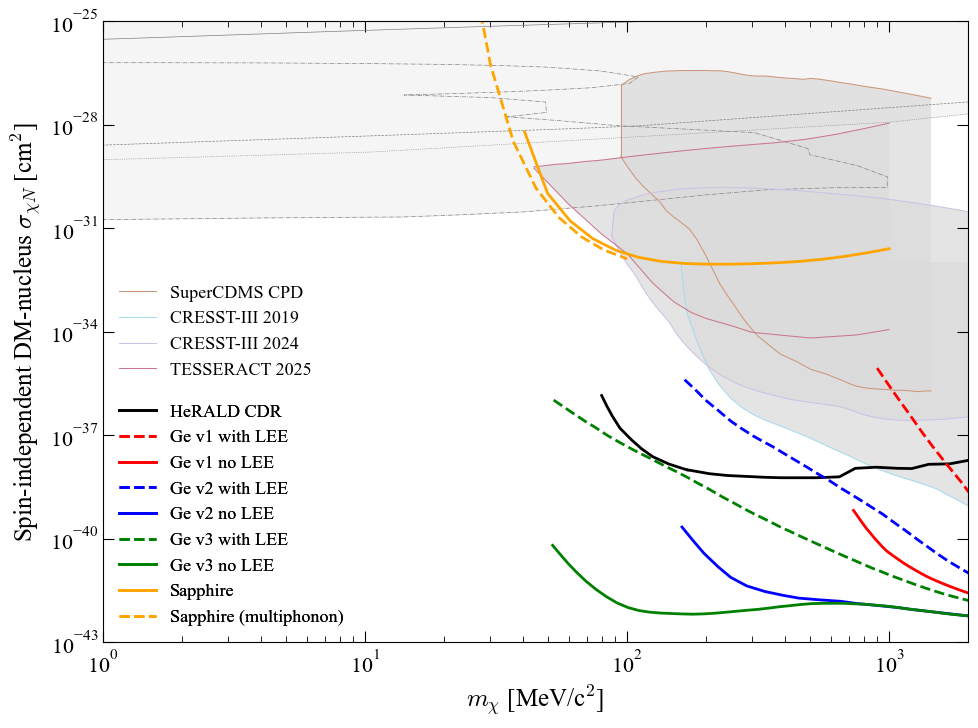

In [6]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)
handles_calculated = []

m_lim, x_lim = np.loadtxt('CDR_Projections/HeRALD_CDR_10x_lower.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='black', linestyle='-', label='HeRALD CDR')
handles_calculated.append(l)

for i, (vn, color) in enumerate(zip([1, 2, 3], ['r', 'b', 'g'])):
    m_lim, x_lim = np.loadtxt(f'CDR_Projections/Ge_v{vn}_with_LEE.txt', unpack=True)
    l, = ax.plot(m_lim*1e3, x_lim, lw=2, color=color, linestyle='--', label=f'Ge v{vn} with LEE')
    handles_calculated.append(l)
    
    m_lim, x_lim = np.loadtxt(f'CDR_Projections/Ge_v{vn}_no_LEE.txt', unpack=True)
    l, =  ax.plot(m_lim*1e3, x_lim, lw=2, color=color, linestyle='-', label=f'Ge v{vn} no LEE')
    handles_calculated.append(l)

m_lim, x_lim = np.loadtxt('projections_2025/sapphire_r57_bkgd_1sec_250meV_NR/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='orange', linestyle='-', label='Sapphire')
handles_calculated.append(l)
m_lim, x_lim = np.loadtxt('projections_2025/sapphire_r57_bkgd_1sec_250meV_phonon_massive/limit.txt', unpack=True)
l, = ax.plot(m_lim*1e3, x_lim, lw=2, color='orange', linestyle='--', label='Sapphire (multiphonon)')
handles_calculated.append(l)

ax.set_xlim([1e0, 2e3])
ax.set_ylim([1e-43, 1e-25])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'Spin-independent DM-nucleus $\sigma_{\chi N}$ [cm$^2$]', fontsize=18)

leg1 = ax.legend(handles=handles_existing, loc='center left', fontsize=13, frameon=False, ncol=1)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_calculated, loc='lower left', fontsize=13, frameon=False, ncol=1)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

## Nuclear Recoils

/tmp/ipykernel_432151/1936742782.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lowervernefinal.loc[lowervernefinal.index[-3:], "Y"] = new_values


(3.0, 500.0)

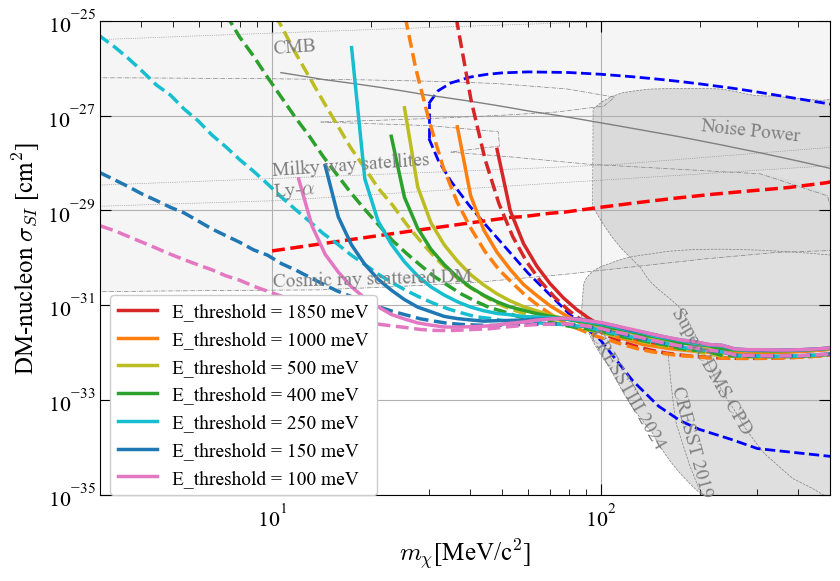

In [ ]:
def parse_column(value):
    value = value.decode('utf-8').strip() 
    if value == "[inf]":                  
        return np.inf
    return float(value.strip("[]"))       

m_list = np.geomspace(0.01, 10, num=25)
extra_values = np.array([0.07, 0.068, 0.065, 0.063, 0.06, 0.058])
m_list = np.sort(np.concatenate((m_list, extra_values)))

dmlimits = np.genfromtxt(
    "ExistingLimits/run47_NRDM_limit_Final.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

sigma_diff = dmlimits[:,1]

# NR
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.set_xlabel(r"$m_\chi $[MeV/c$^2$]")
ax.set_ylabel(r"DM-nucleon $\sigma_{SI}$ [cm$^2$]")

y_interp = np.logspace(np.log10(np.min(ML.Data_Cosmic_ray[:,1])),
                             np.log10(np.max(ML.Data_Cosmic_ray[:,1])),
                             200)
ax.fill_betweenx(y_interp,
                 np.ones(200)*1e-2,
                 np.interp(y_interp, ML.Data_Cosmic_ray[:,1],ML.Data_Cosmic_ray[:,0]),
                facecolor='whitesmoke')
ax.fill_between(ML.Data_Milky_way_satellites_2021[:,0],
                np.ones(len(ML.Data_Milky_way_satellites_2021[:,0]))*1e-22,
                ML.Data_Milky_way_satellites_2021[:,1],
                facecolor='whitesmoke')      
ax.fill_between(ML.Data_Ly_alpha_2022[:,0],
                np.ones(len(ML.Data_Ly_alpha_2022[:,0]))*1e-22,
                ML.Data_Ly_alpha_2022[:,1],
                facecolor='whitesmoke') 


#ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[3],'r--',alpha=0.5)


ax.loglog(ML.Data_Cosmic_ray[:,0],ML.Data_Cosmic_ray[:,1],
         linewidth=0.5, color='gray', linestyle='-.')
ax.text(1e1,2.5e-31,"Cosmic ray scattered DM",color='gray',rotation=1.5)

ax.loglog(ML.Data_Milky_way_satellites_2021[:,0],ML.Data_Milky_way_satellites_2021[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,ML.Data_Milky_way_satellites_2021[11,1],"Milky way satellites",
        color='gray',rotation=4)
ax.loglog(ML.Data_Ly_alpha_2022[:,0],ML.Data_Ly_alpha_2022[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,2e-29,r"Ly-$\alpha$",color='gray',rotation=4)
ax.loglog(ML.Data_CMB[:,0],ML.Data_CMB[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,0.2e-25,"CMB",color='gray',rotation=4)

ax.fill_between(ML.m_interp_mb*1e3, ML.limit_interp_Upper_max, ML.limit_interp_Lower_min, 
                facecolor='silver',alpha=0.5)
#print(np.minimum(ML.CRESSTIII_2024[:,2], np.interp(ML.CRESSTIII_2024[:,0], ML.m_interp_mb, ML.limit_interp_Upper_max)))
mass_fill_2 = np.sort(np.append(ML.m_interp_mb*1e3, ML.CRESSTIII_2024[:61,0]*1e3))
mass_fill_2 = mass_fill_2[mass_fill_2<200]
ax.fill_between(mass_fill_2,
                np.minimum(np.interp(mass_fill_2, ML.CRESSTIII_2024[:,0]*1e3, ML.CRESSTIII_2024[:,2]),
                           np.interp(mass_fill_2, ML.m_interp_mb*1e3, ML.limit_interp_Lower_min)),
                np.interp(mass_fill_2, ML.CRESSTIII_2024[:,0]*1e3, ML.CRESSTIII_2024[:,1]),
                facecolor='silver',alpha=0.5)
ax.loglog(np.vstack((ML.cpdlimit_down[::-1],ML.cpdlimit_up))[:,0]*1e3, np.vstack((ML.cpdlimit_down[::-1],ML.cpdlimit_up))[:,1],
         linewidth=0.5, color='gray', linestyle='--')

ax.text(1.6e2,2e-34,"SuperCDMS CPD",color='gray',rotation=-60)
#ax.text(1.8e2,2e-35,"SuperCDMS  ",color='gray',rotation=-72)
#ax.text(4e2,3e-36,"CPD",color='gray',rotation=-40)
#ax.loglog(cpdlimit_up[:,0]*1e3, cpdlimit_up[:,1])
#ax.loglog(CRESSTlimit_2022[:,0]*1e3,CRESSTlimit_2022[:,1],
#         linewidth=0.5, color='gray', linestyle='--')
#ax.text(1.25e2,5e-34,"CRESST 2023",color='gray',rotation=-60)

ax.loglog(ML.CRESSTlimit_2019[:,0]*1e3,ML.CRESSTlimit_2019[:,1],
         linewidth=0.5, color='gray', linestyle='--')
ax.text(1.6e2,1e-35,"CRESST 2019",color='gray',rotation=-75)

ax.loglog(ML.CRESSTIII_2024[11:,0]*1e3,ML.CRESSTIII_2024[11:,1],
         linewidth=0.5, color='gray', linestyle='--')
ax.loglog(ML.CRESSTIII_2024[11:,0]*1e3,ML.CRESSTIII_2024[11:,2],
         linewidth=0.5, color='gray', linestyle='--')
ax.text(90,1e-34,"CRESSTIII 2024",color='gray',rotation=-60)

#ax.text(0.9e2,3e-34,"CRESST",color='gray',rotation=-80)

#ax.loglog(Data_Nova_SuperCDMS[:,0],Data_Nova_SuperCDMS[:,1], color='purple')
#ax.loglog(Data_Nova_QP[:,0],Data_Nova_QP[:,1],color='orange')
'''
m_sigma_list = np.transpose([np.logspace(-5,0,26),1e-30*np.ones(26)])
ax.loglog(m_sigma_list[:,0]*1e3,limit_mp[2],'k-',label=r'Massive, correlated noise')
ax.text(0.5,2e-28,"Correlated noise",rotation=-15)
#ax.loglog(m_sigma_list[:,0]*1e3,limit_mp[3],'k--',label=r'Massless, correlated noise')
#ax.loglog(m_sigma_list[:,0]*1e3,limit_Uncorr[2],'k-',label=r'Massive, uncorrelated noise')
#ax.text(0.5,1.5e-26,"Uncorrelated noise",rotation=-12)
#ax.loglog(m_sigma_list[:,0]*1e3,limit_Uncorr[3],'b--',label=r'Massless, uncorrelated noise')
ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[2],'r-',alpha=0.5)
ax.text(0.1,1e-28,r'$R_{total}$=1kHz',color='red',alpha=0.5)
'''
#ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[3],'r--',alpha=0.5)



verne_final = pd.read_csv('ExistingLimits/verne_result_final.cvs')
verne_final.columns = ["X", "Y"]
lowervernefinal = verne_final.iloc[:len(verne_final)//2]
uppervernefinal = verne_final.iloc[len(verne_final)//2:]
new_values = [6.564e-35, 8.029e-35, 1.154e-34]  

lowervernefinal.loc[lowervernefinal.index[-3:], "Y"] = new_values

new_row = pd.DataFrame({"X": [0.03], "Y": [3.30520e-28]})
lowervernefinal = pd.concat([new_row, lowervernefinal], ignore_index=True)


verne_unblind = pd.read_csv('ExistingLimits/verne_result_noblind.cvs')
verne_unblind.columns = ["X", "Y"]
lowerverneunblind = verne_unblind.iloc[:len(verne_unblind)//2]
upperverneunblind = verne_unblind.iloc[len(verne_unblind)//2:]
new_values = [5.02397519e-35,6.09179215e-35, 8.57781172e-35]  

verne_unblind.iloc[-3:, 1] = new_values

ax.loglog(lowervernefinal["X"]*1e3, lowervernefinal["Y"],'b--')
#ax.loglog(verne_unblind["X"]*1e3, verne_unblind["Y"],'k--',label='Unrestricted')

ax.loglog(uppervernefinal["X"]*1e3, uppervernefinal["Y"],'b--')


#m_list = lowervernefinal["X"]

#m_list = np.array(m_list)
#lowervernefinal = np.array(lowervernefinal["Y"])

# Ensure sorting is done correctly
#sorted_indices = np.argsort(m_list)
#m_list = m_list[sorted_indices]
#lowervernefinal = lowervernefinal[sorted_indices]


#Noise Limit
NoiseLimit= np.array(np.loadtxt("ExistingLimits/NoiseLimitR47.txt"))

#ax.plot(NoiseLimit[:,0],NoiseLimit[:,1],
#         linewidth=2, color='Black', linestyle='-',label='Noise Limit')


m_list_for_plot = m_list[m_list>=0.045]
sigma_diff_for_plot = sigma_diff[m_list>=0.045] #sigma_diff[m_list>=0.041]
m_list_for_plot=np.insert(m_list_for_plot, 0, 0.045)
sigma_diff_for_plot = np.insert(sigma_diff_for_plot, 0, interpolate.interp1d(m_list,sigma_diff)(0.045))
m_list_for_plot=np.insert(m_list_for_plot, 0, 0.045)

# R_5kHz_60MeV = interpolate.interp1d(m_list, 1e-41*5e3/(0.23e-3*np.array(R_m)/3600/24))(0.045)
# sigma_diff_for_plot = np.insert(sigma_diff_for_plot, 0, R_5kHz_60MeV)
#ax.loglog(m_list_for_plot*1e3,sigma_diff_for_plot,'b',label='TESSERACT\n'+r'1cm$^2$ Device')
#ax.loglog(m_list[:]*1e3,sigma_diff[:],'k--',alpha=0.7,label='No Overburden Lower')



#ax.loglog(lowerverneunblind["X"]*1e3, lowerverneunblind["Y"],'y--')

#ax.loglog(verne_unblind["X"]*1e3, verne_unblind["Y"],'y--')
#ax.loglog(TriggerLimits[:,0]*1e3,TriggerLimits[:,1],'b--',label=r'No boost')
#ax.text(30,10e-34,"",color='b',rotation=-60)
#ax.loglog(np.array(m_list_Upper_8hour_3m[8:])*1e3,limit_Upper_8hour_3m[8:],'b')
m_list_dash = m_list[m_list<=0.045]
sigma_diff_dash= sigma_diff[m_list<=0.045]
#ax.loglog(np.append(np.array(m_list_Upper_8hour_3m[::-1])*1e3, m_list_dash[5:]*1e3),
#          np.append(limit_Upper_8hour_3m[::-1], sigma_diff_dash[5:]),
#          'g--',label='Overburden Constraint',alpha=0.7)

#ax.loglog(np.array(m_list_Upper_8hour_3m[0:8])*1e3,limit_Upper_8hour_3m[0:8],'b--')
#upper limit - 5kHz

# R_5kHz_plot = np.insert(1e-41*5.5e3/(0.23e-3*np.array(R_m)[m_list>=0.045]/3600/24), 0,  R_5kHz_60MeV)
# m_5kHz_plot = np.insert(m_list[m_list>=0.045],0,0.045)
# #ax.loglog(m_5kHz_plot*1e3, R_5kHz_plot,'r--')
# ax.loglog(m_list*1e3, 1e-41*5.5e3/(0.23e-3*np.array(R_m)/3600/24),color='r',linestyle=':',alpha=0.7)
# print(1e-41*5.5e3/(0.23e-3*np.array(R_m)/3600/24))
#ax.text(45,1e-29,r'$R_{Total}$ = 5.5 kHz',color='r',rotation=7)
#ax.text(45,1e-29,'Pileup Constraint',color='r',rotation=7,size = 8)
#ax.text(90,2e-27,'Overburden Constraint',color='g',rotation=-7)
ax.text(4, 3e-32, 'Run 47 Published Limit',color='b')
fillmass = lowervernefinal["X"] 
mask = fillmass > 0.04
fillmass = fillmass[mask] 
fillsig = lowervernefinal["Y"][mask]

corrlimx = [0.06*1e3,0.06*1e3]
corrlimy = [5.05e-31, 7e-30]
#ax.loglog(corrlimx, corrlimy, color = 'purple',linestyle = '-',label = "Mass Cutoff")

# ax.fill_between(fillmass*1e3,
#                 fillsig,
#                  np.interp(fillmass, m_5kHz_plot,R_5kHz_plot),
#                 facecolor='blue',alpha=0.2,label='TESSERACT-Si\n' 'Exclusion')

x_values = [0.03*1e3, 0.03*1e3]  # Same x for both points (vertical line)
y_values = [3.30520e-28, 1.79855e-27]

# Plot the line
ax.loglog(x_values, y_values, 'b--')



# Add Kurinsky curve
das_kurinsky = np.genfromtxt(
    "ExistingLimits/Das_Kurinsky_2024.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

ax.loglog(das_kurinsky[:,0]*1e3, das_kurinsky[:,1], color='gray', linewidth=1.)
ax.text(2e2, 0.3e-27, "Noise Power",color='gray',rotation=-6)



def parse_column(value):
    value = value.decode('utf-8').strip() 
    if value == "[inf]":                  
        return np.inf
    return float(value.strip("[]"))  
oldlims = np.genfromtxt(
    "ExistingLimits/run47_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims = np.genfromtxt(
    "ExistingLimits/run57_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims_sapphire = np.genfromtxt(
    "ExistingLimits/run57_sapphire_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims_sapphire_phonon = np.genfromtxt(
    "ExistingLimits/run57_sapphire_phonon_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

# ax.loglog(oldlims[:,0]*1e3, oldlims[:,1], color='g',label=r"Run 47 Limits - No boost or dRdE",lw=2.5,alpha=0.75)
# ax.loglog(r57lims[:,0]*1e3, r57lims[:,1], color='m',label=r"Run 57 Limits - No boost or dRdE",lw=2.5,alpha=0.75)
# ax.loglog(r57lims_sapphire[:,0]*1e3, r57lims_sapphire[:,1], color='brown',label=r"Run 57 Sapphire",lw=2.5,alpha=0.75)
# ax.loglog(r57lims_sapphire_phonon[:,0]*1e3, r57lims_sapphire_phonon[:,1], '--', color='brown',label=r"Run 57 Sapphire Multiphonon",lw=2.5,alpha=0.75)

r47_pileup = np.genfromtxt(
    "ExistingLimits/TESSERACT_2025_Pileup.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)
ax.loglog(r47_pileup[:,0]*1e3, r47_pileup[:,1], '--', color='r', lw=2.5)
ax.text(4, 8e-33,'Run 47 Pileup Constraint', color='r')


for i, (baseline_meV, color) in \
    enumerate(zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
       
    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV')# + (' (Al2O3)' if i == 0 else ''))

    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_10sec_{baseline_meV}meV_NR/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5)

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

#ax.loglog([0.044*1e3,0.4*1e3],[4e-32,4e-32],'k-')
ax.grid()
ax.legend(loc='lower left', frameon=True, bbox_to_anchor=(0, -0.02), framealpha=1)
ax.set_ylim(1e-35,1e-25)
ax.set_xlim(3e0,5e2)
#fig.savefig('/home/michael/DarkLim/examples/Run47Limit_NR_paper.pdf',bbox_inches="tight")

#print(np.transpose([m_list_for_plot*1e3,sigma_diff_for_plot]))

NameError: name 'plotexcludedNR' is not defined

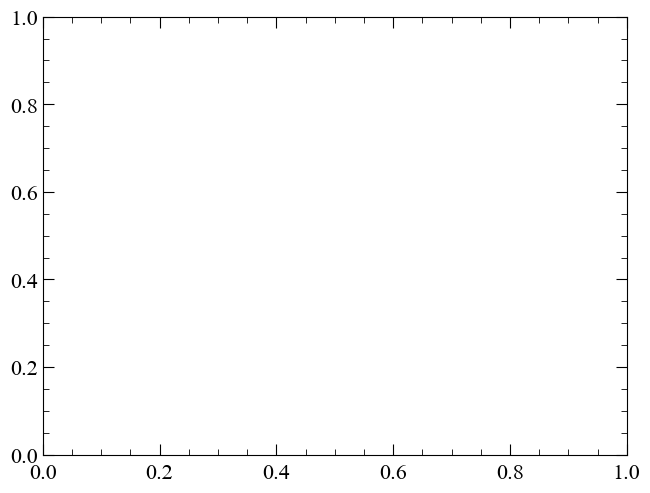

In [ ]:
colors = ['blue','green','darkorange']

lss = ['-','-','-']
    
fig, ax = plt.subplots(1, 1, figsize=(8,6))

plotexcludedNR(ax, details=True)
#leg_params = {'loc':'upper right',
#              'frameon':True,
#              'handlelength':1.5,
#              'fontsize':9,
#              'ncol':3 }
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_NR/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='k', ls='--', lw=2.5, label='Silicon NR')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_phonon_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='c', ls='--', lw=2.5, label='Si multiphonon (massive mediator)')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_phonon_massless/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='b', ls='--', lw=2.5, label='Si multiphonon (massless mediator)')
leg_hands.append(lh)

#ax.text(1e2, 5e-36, r'F$_{DM}$ = 1', fontsize=18)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-39, 2e-20)
ax.set_xlim(1e1, 1e4)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Nucleon Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

#plt.savefig('./pretty_plots/herald_limits_{:0.1f}g_{:0.0f}d.png'.format(mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')

## Run 47 Multiphonon

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)


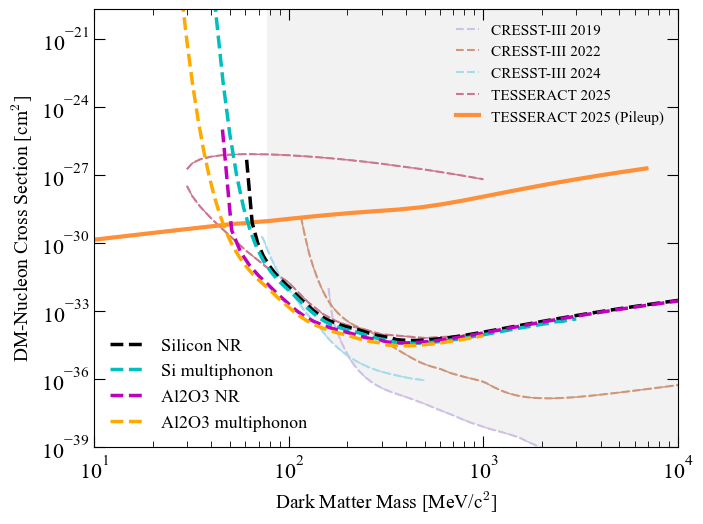

In [ ]:
colors = ['blue','green','darkorange']

lss = ['-','-','-']
    
fig, ax = plt.subplots(1, 1, figsize=(8,6))

plotexcludedNR(ax, details=True)
#leg_params = {'loc':'upper right',
#              'frameon':True,
#              'handlelength':1.5,
#              'fontsize':9,
#              'ncol':3 }
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_NR/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='k', ls='--', lw=2.5, label='Silicon NR')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_phonon_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='c', ls='--', lw=2.5, label='Si multiphonon')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_sapphire_limit_NR/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='m', ls='--', lw=2.5, label='Al2O3 NR')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_sapphire_limit_phonon_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='#ffaa00', ls='--', lw=2.5, label='Al2O3 multiphonon')
leg_hands.append(lh)

#ax.text(1e2, 5e-36, r'F$_{DM}$ = 1', fontsize=18)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-39, 2e-20)
ax.set_xlim(1e1, 1e4)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Nucleon Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

#plt.savefig('./pretty_plots/herald_limits_{:0.1f}g_{:0.0f}d.png'.format(mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')

## Run 47 ER

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


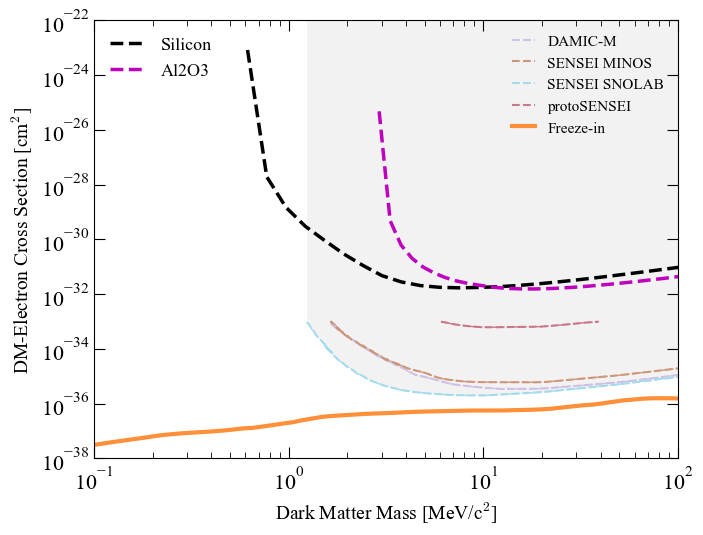

In [ ]:
colors = ['blue','green','darkorange']

lss = ['-','-','-']
    
fig, ax = plt.subplots(1, 1, figsize=(8,6))

plotexcludedmassless(ax, details=True)
#leg_params = {'loc':'upper right',
#              'frameon':True,
#              'handlelength':1.5,
#              'fontsize':9,
#              'ncol':3 }
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='massless')

leg_hands = []

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_electron_massless/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='k', ls='--', lw=2.5, label='Silicon')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_sapphire_limit_electron_massless/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='m', ls='--', lw=2.5, label='Al2O3')
leg_hands.append(lh)

#ax.text(1e2, 5e-36, r'F$_{DM}$ = 1', fontsize=18)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-38, 1e-22)
ax.set_xlim(1e-1, 1e2)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='upper left', fontsize=13)

#plt.savefig('./pretty_plots/herald_limits_{:0.1f}g_{:0.0f}d.png'.format(mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)


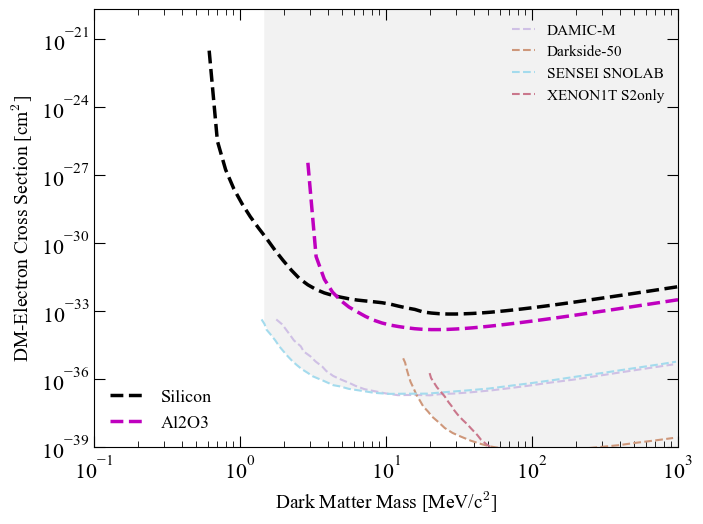

In [ ]:
colors = ['blue','green','darkorange']

lss = ['-','-','-']
    
fig, ax = plt.subplots(1, 1, figsize=(8,6))

plotexcludedmassive(ax, details=False)
#leg_params = {'loc':'upper right',
#              'frameon':True,
#              'handlelength':1.5,
#              'fontsize':9,
#              'ncol':3 }
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='massive')

leg_hands = []

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_limit_electron_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='k', ls='--', lw=2.5, label='Silicon')
leg_hands.append(lh)

m_limit, x_limit = np.loadtxt('Run47_Results/Run47_sapphire_limit_electron_massive/limit.txt', unpack=True)
lh, = plt.plot(m_limit*1e3, x_limit, color='m', ls='--', lw=2.5, label='Al2O3')
leg_hands.append(lh)

#ax.text(1e2, 5e-36, r'F$_{DM}$ = 1', fontsize=18)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-39, 2e-20)
ax.set_xlim(1e-1, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

#plt.savefig('./pretty_plots/herald_limits_{:0.1f}g_{:0.0f}d.png'.format(mass_det*1e3,times[i]),facecolor='white',bbox_inches='tight')

## Projections: Sapphire, Exponential LEE

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)


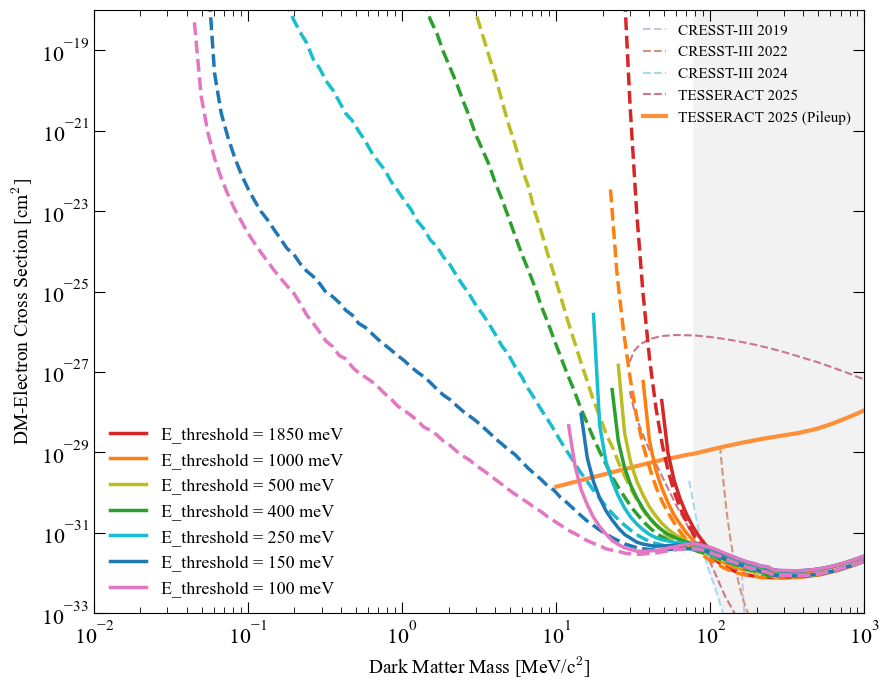

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=False)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

for (baseline_meV, color) in \
    zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
        
    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    lh, = ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')
    leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-33, 1e-18)
ax.set_xlim(1e-2, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


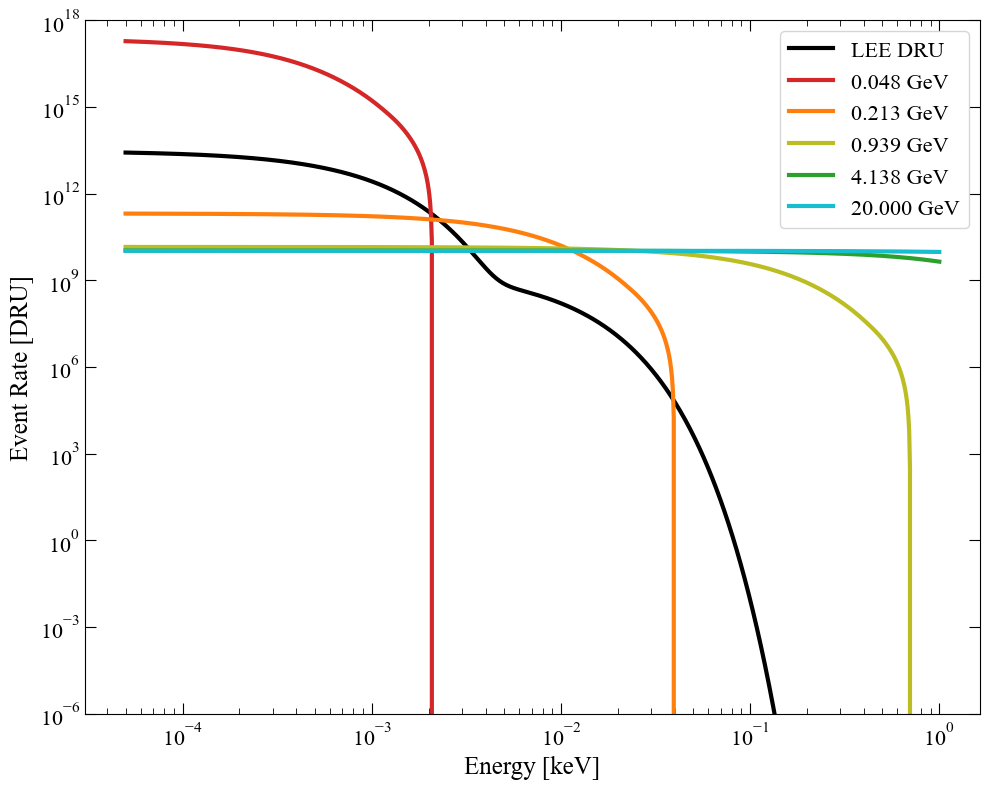

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot LEE spectrum
E_keV = np.geomspace(50e-6, 1, 1000)
dRdE_LEE_DRU = 2.972e13 * np.exp(-1 * E_keV / 4.137e-4) + 2.205e9 * np.exp(-1 * E_keV / 3.808e-3)

ax.plot(E_keV, dRdE_LEE_DRU, 'k-', lw=3, label='LEE DRU')
m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_370meV_NR/limit.txt').transpose()

cut = ~np.isinf(m_limit) * ~np.isinf(x_limit)
m_limit = m_limit[cut]
x_limit = x_limit[cut]

idxs = np.linspace(0, len(m_limit)-1, 5, dtype=int)
for i, (m, x, color) in enumerate(zip(m_limit[idxs],
                                      x_limit[idxs],
                                      ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
    ax.plot(E_keV, darklim.limit.drde(E_keV, m, x, 'Al2O3'), '-', color=color, lw=3, label=f'{m:.3f} GeV')

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-6, 1e18])
ax.set_xscale('log')
ax.legend(loc='best', fontsize=16)
fig.tight_layout()
fig.show()


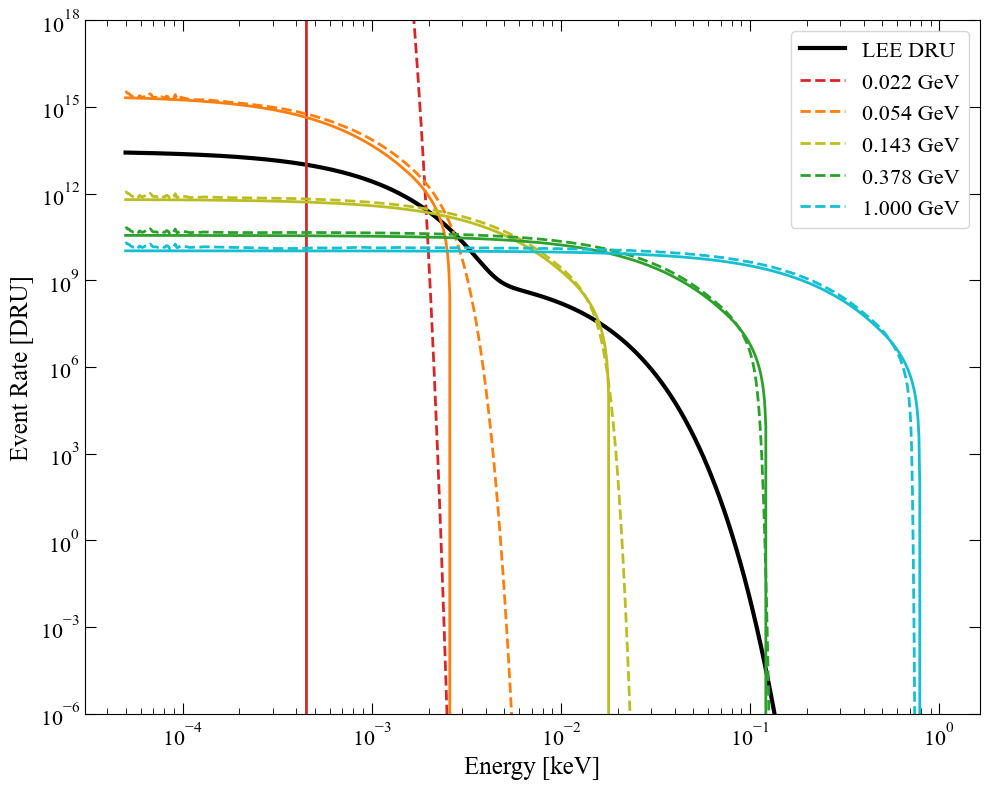

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot LEE spectrum
E_keV = np.geomspace(50e-6, 1, 1000)
dRdE_LEE_DRU = 2.972e13 * np.exp(-1 * E_keV / 4.137e-4) + 2.205e9 * np.exp(-1 * E_keV / 3.808e-3)

ax.plot(E_keV, dRdE_LEE_DRU, 'k-', lw=3, label='LEE DRU')
m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_370meV_phonon_massive/limit.txt').transpose()

cut = ~np.isinf(m_limit) * ~np.isinf(x_limit)
m_limit = m_limit[cut]
x_limit = x_limit[cut]

idxs = np.linspace(0, len(m_limit)-1, 5, dtype=int)
for i, (m, x, color) in enumerate(zip(m_limit[idxs],
                                      x_limit[idxs],
                                      ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
    
    dRdE = darklim.elf.get_dRdE_lambda_Al2O3_phonon(mX_eV=m*1e9, sigman=x, mediator='massive',
                                                    dark_photon=False,
                                                    suppress_darkelf_output=True, gain=1.0)
    dRdE = [dRdE(E) for E in E_keV]
    
    ax.plot(E_keV, darklim.limit.drde(E_keV, m, x, 'Al2O3'), '-', color=color, lw=2)
    ax.plot(E_keV, dRdE, '--', color=color, lw=2, label=f'{m:.3f} GeV')

ax.set_xlabel('Energy [keV]')
ax.set_ylabel('Event Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-6, 1e18])
ax.set_xscale('log')
ax.legend(loc='best', fontsize=16)
fig.tight_layout()
fig.show()


## Projections: Sapphire, Power-Law LEE

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)


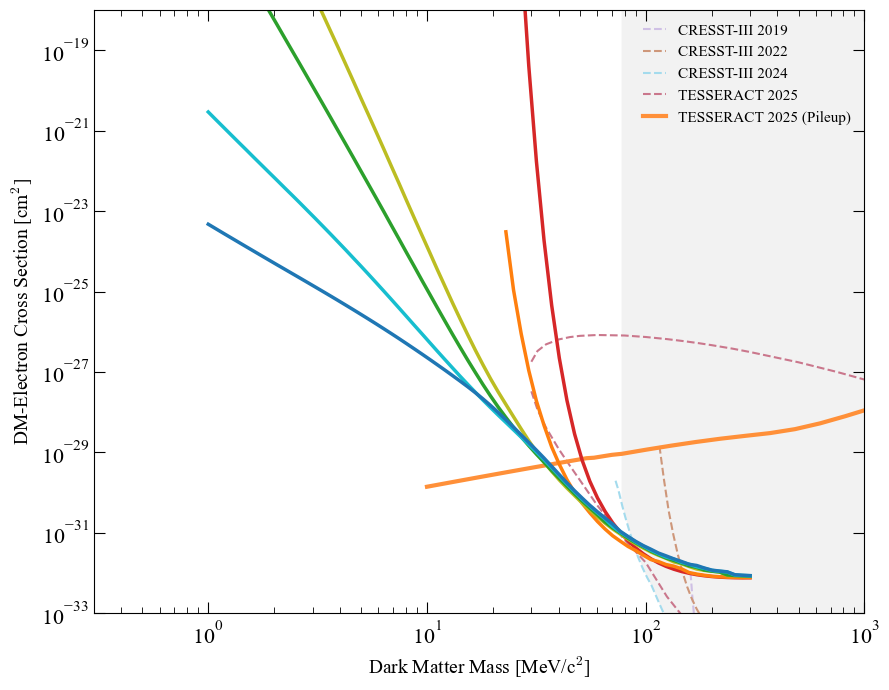

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=False)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

for (baseline_meV, color) in \
    zip([370, 200, 100, 80, 50, 30],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
        
    m_limit, x_limit = np.loadtxt(f'projections/sapphire_power_bkgd_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    #lh, = ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')
    #leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_power_bkgd_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-33, 1e-18)
ax.set_xlim(3e-1, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


## Projections: Silicon

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)


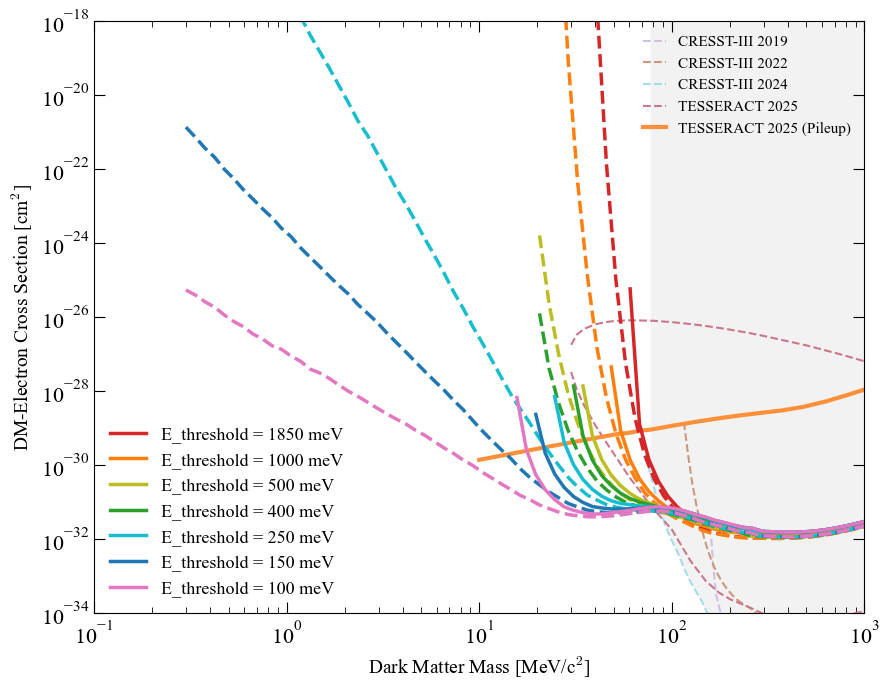

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=False)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []



for (baseline_meV, color) in \
    zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
        
    m_limit, x_limit = np.loadtxt(f'projections/silicon_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')
    leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections/silicon_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)


ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-34, 1e-18)
ax.set_xlim(1e-1, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


## Projections: Silicon and Sapphire, compared

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/3201322330.py:87: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=[l1, l2, l3, l4, l5, l6], **leg_params)
/tmp/ipykernel_979286/1697149380.py:38: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)


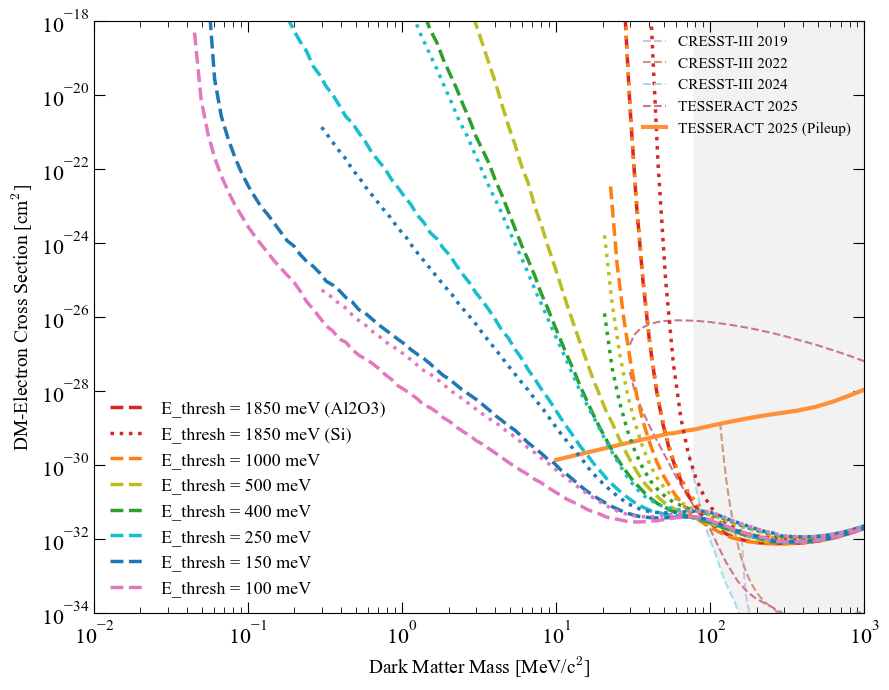

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=False)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

for i, (baseline_meV, color) in \
    enumerate(zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
        
    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV' + (' (Al2O3)' if i == 0 else ''))
    leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections/silicon_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, ':', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV (Si)' if i == 0 else '')
    leg_hands.append(lh)


ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-34, 1e-18)
ax.set_xlim(1e-2, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


# Updated Projections from March 2025

/tmp/ipykernel_979286/3201322330.py:14: RuntimeWarning: All-NaN axis encountered
  result = np.nanmin([result, yinterp], axis=0)
/tmp/ipykernel_979286/2801249495.py:38: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)


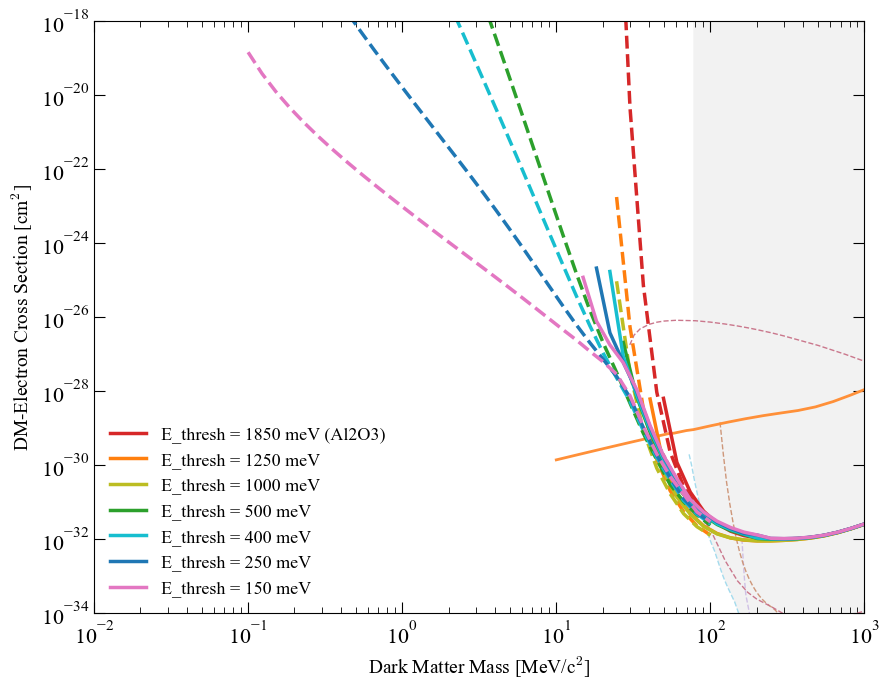

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,7))

plotexcludedNR(ax, details=True)
leg_params = {'loc':'upper right',
              'frameon':False,
              'handlelength':1.5,
              'fontsize':11,
              'ncol':1 }
#load_and_plot_existing(ax,leg=True,lw=1.5,leg_params=leg_params, ER_model='None')

leg_hands = []

for i, (baseline_meV, color) in \
    enumerate(zip([370, 250, 200, 100, 80, 50, 30],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
        
       
    m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV' + (' (Al2O3)' if i == 0 else ''))
    leg_hands.append(lh)

    m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    lh, = plt.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)
    leg_hands.append(lh)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylim(1e-34, 1e-18)
ax.set_xlim(1e-2, 1e3)
ax.set_xlabel("Dark Matter Mass [MeV/c$^2$]", fontsize=14)
ax.set_ylabel("DM-Electron Cross Section [cm$^2$]", fontsize=14)

#ax.grid(lw=0.3,ls='--',color='grey')
#ax.grid(which="minor", linestyle='dotted')
ax.tick_params(which="both", direction="in", right=True, top=True)

ax.legend(handles=leg_hands, frameon=False, ncol=1, loc='lower left', fontsize=13)

fig.tight_layout()
fig.show()


/tmp/ipykernel_979286/2423448193.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lowervernefinal.loc[lowervernefinal.index[-3:], "Y"] = new_values


(3.0, 500.0)

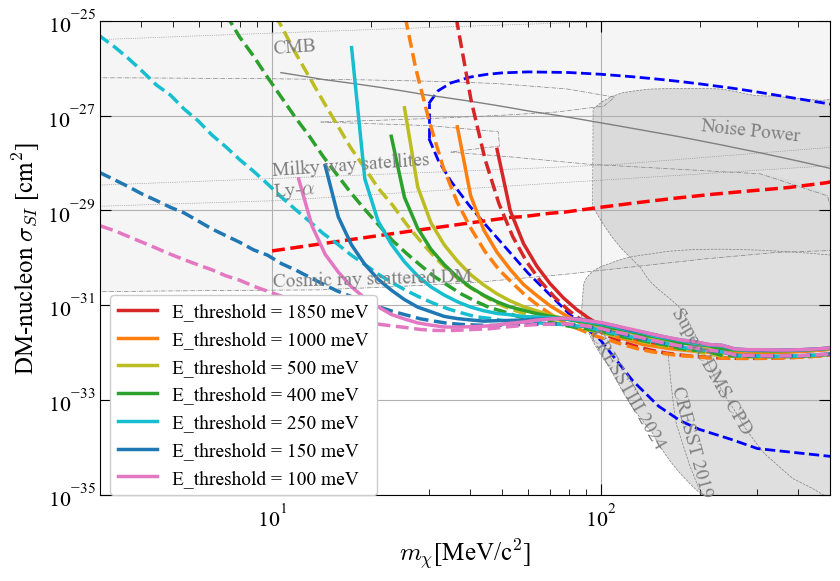

In [ ]:
mpl.rcParams.update({'font.size': 14})
def parse_column(value):
    value = value.decode('utf-8').strip() 
    if value == "[inf]":                  
        return np.inf
    return float(value.strip("[]"))       

m_list = np.geomspace(0.01, 10, num=25)
extra_values = np.array([0.07, 0.068, 0.065, 0.063, 0.06, 0.058])
m_list = np.sort(np.concatenate((m_list, extra_values)))

dmlimits = np.genfromtxt(
    "ExistingLimits/run47_NRDM_limit_Final.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

sigma_diff = dmlimits[:,1]

# NR
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.set_xlabel(r"$m_\chi $[MeV/c$^2$]")
ax.set_ylabel(r"DM-nucleon $\sigma_{SI}$ [cm$^2$]")

y_interp = np.logspace(np.log10(np.min(ML.Data_Cosmic_ray[:,1])),
                             np.log10(np.max(ML.Data_Cosmic_ray[:,1])),
                             200)
ax.fill_betweenx(y_interp,
                 np.ones(200)*1e-2,
                 np.interp(y_interp, ML.Data_Cosmic_ray[:,1],ML.Data_Cosmic_ray[:,0]),
                facecolor='whitesmoke')
ax.fill_between(ML.Data_Milky_way_satellites_2021[:,0],
                np.ones(len(ML.Data_Milky_way_satellites_2021[:,0]))*1e-22,
                ML.Data_Milky_way_satellites_2021[:,1],
                facecolor='whitesmoke')      
ax.fill_between(ML.Data_Ly_alpha_2022[:,0],
                np.ones(len(ML.Data_Ly_alpha_2022[:,0]))*1e-22,
                ML.Data_Ly_alpha_2022[:,1],
                facecolor='whitesmoke') 


#ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[3],'r--',alpha=0.5)


ax.loglog(ML.Data_Cosmic_ray[:,0],ML.Data_Cosmic_ray[:,1],
         linewidth=0.5, color='gray', linestyle='-.')
ax.text(1e1,2.5e-31,"Cosmic ray scattered DM",color='gray',rotation=1.5)

ax.loglog(ML.Data_Milky_way_satellites_2021[:,0],ML.Data_Milky_way_satellites_2021[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,ML.Data_Milky_way_satellites_2021[11,1],"Milky way satellites",
        color='gray',rotation=4)
ax.loglog(ML.Data_Ly_alpha_2022[:,0],ML.Data_Ly_alpha_2022[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,2e-29,r"Ly-$\alpha$",color='gray',rotation=4)
ax.loglog(ML.Data_CMB[:,0],ML.Data_CMB[:,1],
         linewidth=0.5, color='gray', linestyle=':')
ax.text(1e1,0.2e-25,"CMB",color='gray',rotation=4)

ax.fill_between(ML.m_interp_mb*1e3, ML.limit_interp_Upper_max, ML.limit_interp_Lower_min, 
                facecolor='silver',alpha=0.5)
#print(np.minimum(ML.CRESSTIII_2024[:,2], np.interp(ML.CRESSTIII_2024[:,0], ML.m_interp_mb, ML.limit_interp_Upper_max)))
mass_fill_2 = np.sort(np.append(ML.m_interp_mb*1e3, ML.CRESSTIII_2024[:61,0]*1e3))
mass_fill_2 = mass_fill_2[mass_fill_2<200]
ax.fill_between(mass_fill_2,
                np.minimum(np.interp(mass_fill_2, ML.CRESSTIII_2024[:,0]*1e3, ML.CRESSTIII_2024[:,2]),
                           np.interp(mass_fill_2, ML.m_interp_mb*1e3, ML.limit_interp_Lower_min)),
                np.interp(mass_fill_2, ML.CRESSTIII_2024[:,0]*1e3, ML.CRESSTIII_2024[:,1]),
                facecolor='silver',alpha=0.5)
ax.loglog(np.vstack((ML.cpdlimit_down[::-1],ML.cpdlimit_up))[:,0]*1e3, np.vstack((ML.cpdlimit_down[::-1],ML.cpdlimit_up))[:,1],
         linewidth=0.5, color='gray', linestyle='--')

ax.text(1.6e2,2e-34,"SuperCDMS CPD",color='gray',rotation=-60)
#ax.text(1.8e2,2e-35,"SuperCDMS  ",color='gray',rotation=-72)
#ax.text(4e2,3e-36,"CPD",color='gray',rotation=-40)
#ax.loglog(cpdlimit_up[:,0]*1e3, cpdlimit_up[:,1])
#ax.loglog(CRESSTlimit_2022[:,0]*1e3,CRESSTlimit_2022[:,1],
#         linewidth=0.5, color='gray', linestyle='--')
#ax.text(1.25e2,5e-34,"CRESST 2023",color='gray',rotation=-60)

ax.loglog(ML.CRESSTlimit_2019[:,0]*1e3,ML.CRESSTlimit_2019[:,1],
         linewidth=0.5, color='gray', linestyle='--')
ax.text(1.6e2,1e-35,"CRESST 2019",color='gray',rotation=-75)

ax.loglog(ML.CRESSTIII_2024[11:,0]*1e3,ML.CRESSTIII_2024[11:,1],
         linewidth=0.5, color='gray', linestyle='--')
ax.loglog(ML.CRESSTIII_2024[11:,0]*1e3,ML.CRESSTIII_2024[11:,2],
         linewidth=0.5, color='gray', linestyle='--')
ax.text(90,1e-34,"CRESSTIII 2024",color='gray',rotation=-60)

#ax.text(0.9e2,3e-34,"CRESST",color='gray',rotation=-80)

#ax.loglog(Data_Nova_SuperCDMS[:,0],Data_Nova_SuperCDMS[:,1], color='purple')
#ax.loglog(Data_Nova_QP[:,0],Data_Nova_QP[:,1],color='orange')
'''
m_sigma_list = np.transpose([np.logspace(-5,0,26),1e-30*np.ones(26)])
ax.loglog(m_sigma_list[:,0]*1e3,limit_mp[2],'k-',label=r'Massive, correlated noise')
ax.text(0.5,2e-28,"Correlated noise",rotation=-15)
#ax.loglog(m_sigma_list[:,0]*1e3,limit_mp[3],'k--',label=r'Massless, correlated noise')
#ax.loglog(m_sigma_list[:,0]*1e3,limit_Uncorr[2],'k-',label=r'Massive, uncorrelated noise')
#ax.text(0.5,1.5e-26,"Uncorrelated noise",rotation=-12)
#ax.loglog(m_sigma_list[:,0]*1e3,limit_Uncorr[3],'b--',label=r'Massless, uncorrelated noise')
ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[2],'r-',alpha=0.5)
ax.text(0.1,1e-28,r'$R_{total}$=1kHz',color='red',alpha=0.5)
'''
#ax.loglog(m_sigma_list[:,0]*1e3,limit_rate[3],'r--',alpha=0.5)



verne_final = pd.read_csv('ExistingLimits/verne_result_final.cvs')
verne_final.columns = ["X", "Y"]
lowervernefinal = verne_final.iloc[:len(verne_final)//2]
uppervernefinal = verne_final.iloc[len(verne_final)//2:]
new_values = [6.564e-35, 8.029e-35, 1.154e-34]  

lowervernefinal.loc[lowervernefinal.index[-3:], "Y"] = new_values

new_row = pd.DataFrame({"X": [0.03], "Y": [3.30520e-28]})
lowervernefinal = pd.concat([new_row, lowervernefinal], ignore_index=True)


verne_unblind = pd.read_csv('ExistingLimits/verne_result_noblind.cvs')
verne_unblind.columns = ["X", "Y"]
lowerverneunblind = verne_unblind.iloc[:len(verne_unblind)//2]
upperverneunblind = verne_unblind.iloc[len(verne_unblind)//2:]
new_values = [5.02397519e-35,6.09179215e-35, 8.57781172e-35]  

verne_unblind.iloc[-3:, 1] = new_values

ax.loglog(lowervernefinal["X"]*1e3, lowervernefinal["Y"],'b--')
#ax.loglog(verne_unblind["X"]*1e3, verne_unblind["Y"],'k--',label='Unrestricted')

ax.loglog(uppervernefinal["X"]*1e3, uppervernefinal["Y"],'b--')


#m_list = lowervernefinal["X"]

#m_list = np.array(m_list)
#lowervernefinal = np.array(lowervernefinal["Y"])

# Ensure sorting is done correctly
#sorted_indices = np.argsort(m_list)
#m_list = m_list[sorted_indices]
#lowervernefinal = lowervernefinal[sorted_indices]


#Noise Limit
NoiseLimit= np.array(np.loadtxt("ExistingLimits/NoiseLimitR47.txt"))

#ax.plot(NoiseLimit[:,0],NoiseLimit[:,1],
#         linewidth=2, color='Black', linestyle='-',label='Noise Limit')


m_list_for_plot = m_list[m_list>=0.045]
sigma_diff_for_plot = sigma_diff[m_list>=0.045] #sigma_diff[m_list>=0.041]
m_list_for_plot=np.insert(m_list_for_plot, 0, 0.045)
sigma_diff_for_plot = np.insert(sigma_diff_for_plot, 0, interpolate.interp1d(m_list,sigma_diff)(0.045))
m_list_for_plot=np.insert(m_list_for_plot, 0, 0.045)

# R_5kHz_60MeV = interpolate.interp1d(m_list, 1e-41*5e3/(0.23e-3*np.array(R_m)/3600/24))(0.045)
# sigma_diff_for_plot = np.insert(sigma_diff_for_plot, 0, R_5kHz_60MeV)
#ax.loglog(m_list_for_plot*1e3,sigma_diff_for_plot,'b',label='TESSERACT\n'+r'1cm$^2$ Device')
#ax.loglog(m_list[:]*1e3,sigma_diff[:],'k--',alpha=0.7,label='No Overburden Lower')



#ax.loglog(lowerverneunblind["X"]*1e3, lowerverneunblind["Y"],'y--')

#ax.loglog(verne_unblind["X"]*1e3, verne_unblind["Y"],'y--')
#ax.loglog(TriggerLimits[:,0]*1e3,TriggerLimits[:,1],'b--',label=r'No boost')
#ax.text(30,10e-34,"",color='b',rotation=-60)
#ax.loglog(np.array(m_list_Upper_8hour_3m[8:])*1e3,limit_Upper_8hour_3m[8:],'b')
m_list_dash = m_list[m_list<=0.045]
sigma_diff_dash= sigma_diff[m_list<=0.045]
#ax.loglog(np.append(np.array(m_list_Upper_8hour_3m[::-1])*1e3, m_list_dash[5:]*1e3),
#          np.append(limit_Upper_8hour_3m[::-1], sigma_diff_dash[5:]),
#          'g--',label='Overburden Constraint',alpha=0.7)

#ax.loglog(np.array(m_list_Upper_8hour_3m[0:8])*1e3,limit_Upper_8hour_3m[0:8],'b--')
#upper limit - 5kHz

# R_5kHz_plot = np.insert(1e-41*5.5e3/(0.23e-3*np.array(R_m)[m_list>=0.045]/3600/24), 0,  R_5kHz_60MeV)
# m_5kHz_plot = np.insert(m_list[m_list>=0.045],0,0.045)
# #ax.loglog(m_5kHz_plot*1e3, R_5kHz_plot,'r--')
# ax.loglog(m_list*1e3, 1e-41*5.5e3/(0.23e-3*np.array(R_m)/3600/24),color='r',linestyle=':',alpha=0.7)
# print(1e-41*5.5e3/(0.23e-3*np.array(R_m)/3600/24))
#ax.text(45,1e-29,r'$R_{Total}$ = 5.5 kHz',color='r',rotation=7)
#ax.text(45,1e-29,'Pileup Constraint',color='r',rotation=7,size = 8)
#ax.text(90,2e-27,'Overburden Constraint',color='g',rotation=-7)
ax.text(4, 3e-32, 'Run 47 Published Limit',color='b')
fillmass = lowervernefinal["X"] 
mask = fillmass > 0.04
fillmass = fillmass[mask] 
fillsig = lowervernefinal["Y"][mask]

corrlimx = [0.06*1e3,0.06*1e3]
corrlimy = [5.05e-31, 7e-30]
#ax.loglog(corrlimx, corrlimy, color = 'purple',linestyle = '-',label = "Mass Cutoff")

# ax.fill_between(fillmass*1e3,
#                 fillsig,
#                  np.interp(fillmass, m_5kHz_plot,R_5kHz_plot),
#                 facecolor='blue',alpha=0.2,label='TESSERACT-Si\n' 'Exclusion')

x_values = [0.03*1e3, 0.03*1e3]  # Same x for both points (vertical line)
y_values = [3.30520e-28, 1.79855e-27]

# Plot the line
ax.loglog(x_values, y_values, 'b--')



# Add Kurinsky curve
das_kurinsky = np.genfromtxt(
    "ExistingLimits/Das_Kurinsky_2024.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

ax.loglog(das_kurinsky[:,0]*1e3, das_kurinsky[:,1], color='gray', linewidth=1.)
ax.text(2e2, 0.3e-27, "Noise Power",color='gray',rotation=-6)



def parse_column(value):
    value = value.decode('utf-8').strip() 
    if value == "[inf]":                  
        return np.inf
    return float(value.strip("[]"))  
oldlims = np.genfromtxt(
    "ExistingLimits/run47_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims = np.genfromtxt(
    "ExistingLimits/run57_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims_sapphire = np.genfromtxt(
    "ExistingLimits/run57_sapphire_NRDM_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

r57lims_sapphire_phonon = np.genfromtxt(
    "ExistingLimits/run57_sapphire_phonon_limit_noboost_nodrde.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)

# ax.loglog(oldlims[:,0]*1e3, oldlims[:,1], color='g',label=r"Run 47 Limits - No boost or dRdE",lw=2.5,alpha=0.75)
# ax.loglog(r57lims[:,0]*1e3, r57lims[:,1], color='m',label=r"Run 57 Limits - No boost or dRdE",lw=2.5,alpha=0.75)
# ax.loglog(r57lims_sapphire[:,0]*1e3, r57lims_sapphire[:,1], color='brown',label=r"Run 57 Sapphire",lw=2.5,alpha=0.75)
# ax.loglog(r57lims_sapphire_phonon[:,0]*1e3, r57lims_sapphire_phonon[:,1], '--', color='brown',label=r"Run 57 Sapphire Multiphonon",lw=2.5,alpha=0.75)

r47_pileup = np.genfromtxt(
    "ExistingLimits/TESSERACT_2025_Pileup.txt",
    dtype=float,
    converters={1: parse_column}, 
    delimiter=None                 
)
ax.loglog(r47_pileup[:,0]*1e3, r47_pileup[:,1], '--', color='r', lw=2.5)
ax.text(4, 8e-33,'Run 47 Pileup Constraint', color='r')


for i, (baseline_meV, color) in \
    enumerate(zip([370, 200, 100, 80, 50, 30, 20],
        ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):
       
    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_thresh = {5*baseline_meV} meV')# + (' (Al2O3)' if i == 0 else ''))

    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

    # m_limit, x_limit = np.loadtxt(f'projections_2025/sapphire_r57_bkgd_10sec_{baseline_meV}meV_NR/limit.txt').transpose()
    # ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5)

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_NR/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '-', color=color, lw=2.5, label=f'E_threshold = {baseline_meV*5} meV')

    m_limit, x_limit = np.loadtxt(f'projections/sapphire_1sec_{baseline_meV}meV_phonon_massive/limit.txt').transpose()
    ax.plot(m_limit*1e3, x_limit, '--', color=color, lw=2.5)

#ax.loglog([0.044*1e3,0.4*1e3],[4e-32,4e-32],'k-')
ax.grid()
ax.legend(loc='lower left', frameon=True, bbox_to_anchor=(0, -0.02), framealpha=1)
ax.set_ylim(1e-35,1e-25)
ax.set_xlim(3e0,5e2)
#fig.savefig('/home/michael/DarkLim/examples/Run47Limit_NR_paper.pdf',bbox_inches="tight")

#print(np.transpose([m_list_for_plot*1e3,sigma_diff_for_plot]))